# **Import Neccesary Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
plt.figure(figsize=(12,6))
sns.set_style('whitegrid')
print("Libraries Loaded!!")

Libraries Loaded!!


<Figure size 1200x600 with 0 Axes>

# **EDA**

## *Load The Data*

In [2]:
df = pd.read_csv("C:\\Users\\abhay\\OneDrive\\Desktop\\ML learning\\Linear Regression\\Gym Calories\\Data\\gym_calories.csv")
print("Data Loaded")

Data Loaded


## *Data Exploration*

In [3]:
print(f"The Given Data have {df.shape} shape")

The Given Data have (521, 7) shape


In [4]:
#First 5 Rows
df.head()

,age,weight_kg,workout_duration_min,avg_heart_rate,workout_intensity,water_intake_liters,calories_burned
0,22.0,110.5,53.0,119.0,4.0,2.9,565.7
1,49.0,111.5,52.0,98.0,8.0,4.0,549.8
2,23.0,45.8,58.0,154.0,1.0,3.7,492.1
3,47.0,111.5,65.0,148.0,8.0,3.0,656.4
4,-8.0,65.4,111.0,153.0,8.0,0.9,742.6


In [5]:
#Last 5 Rows
df.tail()

,age,weight_kg,workout_duration_min,avg_heart_rate,workout_intensity,water_intake_liters,calories_burned
516,58.0,101.8,90.0,93.0,1.0,2.5,599.2
517,-8.0,65.4,111.0,153.0,8.0,0.9,742.6
518,46.0,73.6,27.0,109.0,3.0,2.7,385.2
519,59.0,108.0,90.0,136.0,7.0,1.6,709.2
520,46.0,64.9,105.0,96.0,2.0,2.0,603.5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   521 non-null    float64
 1   weight_kg             521 non-null    float64
 2   workout_duration_min  521 non-null    float64
 3   avg_heart_rate        501 non-null    float64
 4   workout_intensity     521 non-null    float64
 5   water_intake_liters   505 non-null    float64
 6   calories_burned       521 non-null    float64
dtypes: float64(7)
memory usage: 28.6 KB


In [7]:
df.describe()

,age,weight_kg,workout_duration_min,avg_heart_rate,workout_intensity,water_intake_liters,calories_burned
count,521.000000,521.000000,521.000000,501.000000,521.000000,505.000000,521.000000
mean,40.318618,81.744722,68.030710,134.538922,5.499040,2.271089,601.717658
std,13.876454,22.144357,35.398487,25.583764,2.851535,0.990649,428.062439
min,-8.000000,45.100000,15.000000,90.000000,1.000000,0.500000,320.400000
25%,28.000000,62.600000,41.000000,114.000000,3.000000,1.400000,495.100000
50%,41.000000,81.300000,67.000000,135.000000,6.000000,2.200000,588.000000
75%,51.000000,99.500000,93.000000,155.000000,8.000000,3.100000,670.400000
max,64.000000,119.900000,500.000000,179.000000,10.000000,4.000000,9999.000000


In [8]:
# relationship Between Different Col
df.corr()

,age,weight_kg,workout_duration_min,avg_heart_rate,workout_intensity,water_intake_liters,calories_burned
age,1.000000,0.093430,-0.042670,-0.053502,0.024162,0.008764,-0.018678
weight_kg,0.093430,1.000000,-0.012036,0.021982,-0.053230,0.022160,0.069030
workout_duration_min,-0.042670,-0.012036,1.000000,0.028694,-0.105336,0.018090,0.243102
avg_heart_rate,-0.053502,0.021982,0.028694,1.000000,0.012564,0.029577,0.099638
workout_intensity,0.024162,-0.053230,-0.105336,0.012564,1.000000,-0.042798,0.007138
water_intake_liters,0.008764,0.022160,0.018090,0.029577,-0.042798,1.000000,-0.028007
calories_burned,-0.018678,0.069030,0.243102,0.099638,0.007138,-0.028007,1.000000


In [9]:
# NaN values
print("The NaN values in data is as follows:-")
df.isna().sum()

The NaN values in data is as follows:-


age                      0
weight_kg                0
workout_duration_min     0
avg_heart_rate          20
workout_intensity        0
water_intake_liters     16
calories_burned          0
dtype: int64

In [10]:
# Duplicates in Data
print(f"The duplicates in the Dataset is {df.duplicated().sum()}")

The duplicates in the Dataset is 11


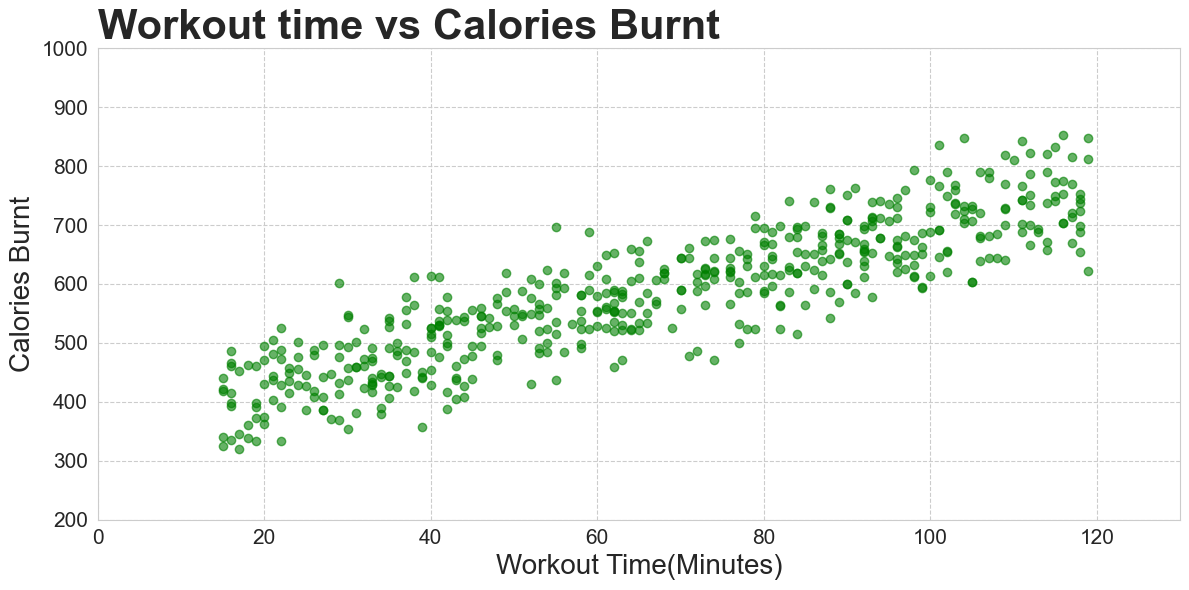

In [11]:
# reationship B/W Calories Burnt And Workout time
plt.figure(figsize=(12,6))
plt.scatter(df['workout_duration_min'],df['calories_burned'],alpha=0.6,color = 'green')
plt.xlim(0,130)
plt.ylim(200,1000)
plt.xlabel("Workout Time(Minutes)",fontsize=20)
plt.ylabel("Calories Burnt",fontsize=20)
plt.title('Workout time vs Calories Burnt',weight = 'bold',fontsize=30,loc='left')
ax = plt.gca()
ax.tick_params('both',labelsize = 15)
plt.grid(visible=True,linestyle='--')
plt.tight_layout()
plt.show()

# **Data Cleaning**

In [12]:
# Create a Copy of Original Data
df_copy = df.copy()

## *Impossible Values*

In [21]:
# finding the values that looks suspecious and replace them with median
df_copy.loc[df_copy['age']<1,'age'] = df_copy['age'].median()
df_copy.loc[df_copy['workout_duration_min']>120,'workout_duration_min'] = df_copy['workout_duration_min'].median()


## *Outliers Handaling*

In [25]:
Q1 = df_copy['calories_burned'].quantile(0.25)
Q3 = df_copy['calories_burned'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_copy.loc[df_copy['calories_burned'] < lower, 'calories_burned'] = np.nan
df_copy.loc[df_copy['calories_burned'] > upper, 'calories_burned'] = np.nan

print("Outliers Handeled")

Outliers Handeled


## *Filling NaN Values*

In [33]:
print("NaN Values Before:- ")
print(df_copy.isna().sum())

df_copy['avg_heart_rate'] = df_copy['avg_heart_rate'].fillna(round(df_copy['avg_heart_rate'].median(),2))
df_copy['water_intake_liters'] = df_copy['water_intake_liters'].fillna(round(df_copy['water_intake_liters'].median(),2))
df_copy['calories_burned'] = df_copy['calories_burned'].fillna(round(df_copy['calories_burned'].median(),2))
print("\nNaN values After:- ")
print(df_copy.isna().sum())

NaN Values Before:- 
age                      0
weight_kg                0
workout_duration_min     0
avg_heart_rate          20
workout_intensity        0
water_intake_liters     16
calories_burned          1
dtype: int64

NaN values After:- 
age                     0
weight_kg               0
workout_duration_min    0
avg_heart_rate          0
workout_intensity       0
water_intake_liters     0
calories_burned         0
dtype: int64


## *Drop Duplicates*

In [35]:
df_copy.drop_duplicates(inplace=True)
print("Duplicates Dropped Successfully")

Duplicates Dropped Successfully


## *Double Check The Clean Data*

In [42]:
print(f"Shape : {df_copy.shape}\n")
print(f"{df_copy.info()}")

Shape : (510, 7)

<class 'pandas.core.frame.DataFrame'>
Index: 510 entries, 0 to 509
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   510 non-null    float64
 1   weight_kg             510 non-null    float64
 2   workout_duration_min  510 non-null    float64
 3   avg_heart_rate        510 non-null    float64
 4   workout_intensity     510 non-null    float64
 5   water_intake_liters   510 non-null    float64
 6   calories_burned       510 non-null    float64
dtypes: float64(7)
memory usage: 31.9 KB
None


# **Visual**

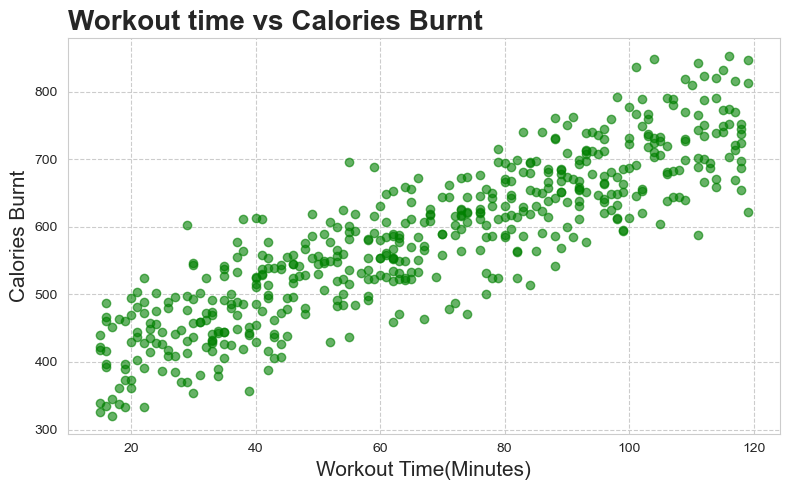

In [49]:
plt.figure(figsize=(8,5))
plt.scatter(df_copy['workout_duration_min'],df_copy['calories_burned'],alpha=0.6,color = 'green')
plt.xlabel("Workout Time(Minutes)",fontsize=15)
plt.ylabel("Calories Burnt",fontsize=15)
plt.title('Workout time vs Calories Burnt',weight = 'bold',fontsize=20,loc='left')
ax = plt.gca()
ax.tick_params('both',labelsize = 10)
plt.grid(visible=True,linestyle='--')
plt.tight_layout()
plt.show()